In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline

# Анализ данных

In [25]:
df = pd.read_csv('listings.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,3176,Fabulous Flat in great Location,3718,Britta,Pankow,Prenzlauer Berg Südwest,52.53471,13.41810,Entire home/apt,105.0,63,148,2023-05-25,0.81,1,272,0,First name and Last name: Nicolas Krotz <br/> ...
1,9991,Geourgeous flat - outstanding views,33852,Philipp,Pankow,Prenzlauer Berg Südwest,52.53269,13.41805,Entire home/apt,180.0,6,7,2020-01-04,0.06,1,32,0,03/Z/RA/003410-18
2,14325,Studio Apartment in Prenzlauer Berg,55531,Chris + Oliver,Pankow,Prenzlauer Berg Nordwest,52.54813,13.40366,Entire home/apt,70.0,150,26,2023-11-30,0.15,4,185,1,NaN
3,16644,In the Heart of Berlin - Kreuzberg,64696,Rene,Friedrichshain-Kreuzberg,nördliche Luisenstadt,52.50312,13.43508,Entire home/apt,90.0,93,48,2017-12-14,0.28,2,0,0,NaN
4,17904,Beautiful Kreuzberg studio - 3 months minimum,68997,Matthias,Neukölln,Reuterstraße,52.49419,13.42166,Entire home/apt,25.0,92,299,2022-12-01,1.71,1,1,0,NaN


## One-hot encoding

In [16]:
df = pd.get_dummies(df, columns=['neighbourhood_group', 'neighbourhood'])

df.head()

,id,name,host_id,host_name,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,...,neighbourhood_West 3,neighbourhood_West 4,neighbourhood_West 5,neighbourhood_Westend,neighbourhood_Wiesbadener Straße,neighbourhood_Wilhelmstadt,neighbourhood_Zehlendorf Nord,neighbourhood_Zehlendorf Südwest,neighbourhood_nördliche Luisenstadt,neighbourhood_südliche Luisenstadt
0,3176,Fabulous Flat in great Location,3718,Britta,52.53471,13.41810,Entire home/apt,105.0,63,148,...,False,False,False,False,False,False,False,False,False,False
1,9991,Geourgeous flat - outstanding views,33852,Philipp,52.53269,13.41805,Entire home/apt,180.0,6,7,...,False,False,False,False,False,False,False,False,False,False
2,14325,Studio Apartment in Prenzlauer Berg,55531,Chris + Oliver,52.54813,13.40366,Entire home/apt,70.0,150,26,...,False,False,False,False,False,False,False,False,False,False
3,16644,In the Heart of Berlin - Kreuzberg,64696,Rene,52.50312,13.43508,Entire home/apt,90.0,93,48,...,False,False,False,False,False,False,False,False,True,False
4,17904,Beautiful Kreuzberg studio - 3 months minimum,68997,Matthias,52.49419,13.42166,Entire home/apt,25.0,92,299,...,False,False,False,False,False,False,False,False,False,False


In [17]:
df = pd.read_csv('listings.csv')
df = pd.get_dummies(df, columns=['neighbourhood_group', 'neighbourhood'], drop_first=True)

df.head()

,id,name,host_id,host_name,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,...,neighbourhood_West 3,neighbourhood_West 4,neighbourhood_West 5,neighbourhood_Westend,neighbourhood_Wiesbadener Straße,neighbourhood_Wilhelmstadt,neighbourhood_Zehlendorf Nord,neighbourhood_Zehlendorf Südwest,neighbourhood_nördliche Luisenstadt,neighbourhood_südliche Luisenstadt
0,3176,Fabulous Flat in great Location,3718,Britta,52.53471,13.41810,Entire home/apt,105.0,63,148,...,False,False,False,False,False,False,False,False,False,False
1,9991,Geourgeous flat - outstanding views,33852,Philipp,52.53269,13.41805,Entire home/apt,180.0,6,7,...,False,False,False,False,False,False,False,False,False,False
2,14325,Studio Apartment in Prenzlauer Berg,55531,Chris + Oliver,52.54813,13.40366,Entire home/apt,70.0,150,26,...,False,False,False,False,False,False,False,False,False,False
3,16644,In the Heart of Berlin - Kreuzberg,64696,Rene,52.50312,13.43508,Entire home/apt,90.0,93,48,...,False,False,False,False,False,False,False,False,True,False
4,17904,Beautiful Kreuzberg studio - 3 months minimum,68997,Matthias,52.49419,13.42166,Entire home/apt,25.0,92,299,...,False,False,False,False,False,False,False,False,False,False


## Работа с пропусками

In [26]:
df.isnull().sum()

id                                   0
name                                 0
host_id                              0
host_name                            9
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             4938
minimum_nights                       0
number_of_reviews                    0
last_review                       3238
reviews_per_month                 3238
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           4956
dtype: int64

In [27]:
df['reviews_per_month'].fillna((df['reviews_per_month'].mean()), inplace=True)
df.isnull().sum()

C:\Users\melni\AppData\Local\Temp\ipykernel_18996\3301812625.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna((df['reviews_per_month'].mean()), inplace=True)


id                                   0
name                                 0
host_id                              0
host_name                            9
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             4938
minimum_nights                       0
number_of_reviews                    0
last_review                       3238
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           4956
dtype: int64

In [32]:
df = pd.read_csv('listings.csv')
df['reviews_per_month'] = df['reviews_per_month'].fillna(df['reviews_per_month'].mode())
df.isnull().sum()

id                                   0
name                                 0
host_id                              0
host_name                            9
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             4938
minimum_nights                       0
number_of_reviews                    0
last_review                       3238
reviews_per_month                 3238
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           4956
dtype: int64

In [36]:
df = pd.read_csv('listings.csv')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['reviews_per_month'].isnull().sum()

np.int64(0)

In [ ]:
df.dropna(axis=0, how='any', thresh=None, subset=None, inplace=True)

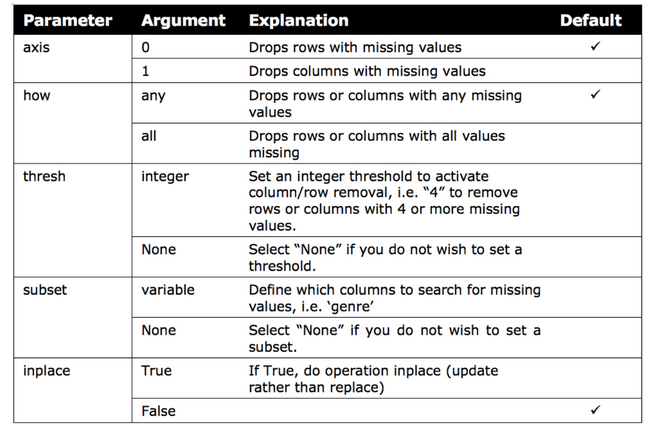